# Node-Level Inflow Prediction From GMEL Embeddings

This notebook explores a simpler, node-level alternative to the `GMEL -> GBRT` edge-flow pipeline.

Instead of predicting one OD flow `(src, dst) -> count`, we predict the **total inflow of a destination node** from its GMEL destination embedding.

Workflow:
1. Load the trained GMEL checkpoint and compute destination embeddings.
2. Build node-level inflow targets by aggregating all edges across train/valid/test.
3. Split nodes into held-out train/valid/test sets.
4. Train a small differentiable MLP regressor on destination embeddings.
5. Report validation/test results and visualize predictions.

This gives us a node prediction task that is more natural for node-level counterfactual methods.

## 1. Imports

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import utils
from model import MyModel

warnings.filterwarnings(
    "ignore",
    message="Feature table contains NaN. 0 is used to fill these NaNs"
)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cwd:", os.getcwd())

torch: 2.3.0
cuda available: True
cwd: c:\Users\qshah\Documents\Spring 2026\GMEL\code


## 2. Config

In [2]:
YEAR = 2015
NUM_HIDDEN_LAYERS = 1
EMBEDDING_SIZE = 128
MULTITASK_WEIGHTS = (0.5, 0.25, 0.25)

# Keep this on CPU unless utils.build_graph_from_matrix is updated for CUDA graph construction.
DEVICE = "cpu"
SEED = 42

TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15

BATCH_SIZE = 128
MAX_EPOCHS = 500
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 100

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device(DEVICE)

assert abs(TRAIN_RATIO + VALID_RATIO + TEST_RATIO - 1.0) < 1e-8
print("Using device:", device)
print("GMEL config:", YEAR, NUM_HIDDEN_LAYERS, EMBEDDING_SIZE, MULTITASK_WEIGHTS)

Using device: cpu
GMEL config: 2015 1 128 (0.5, 0.25, 0.25)


## 3. Load Data and GMEL Checkpoint

In [3]:
data = utils.load_dataset(year=YEAR)

node_feats = data["node_feats"].astype(np.float32)
ct_adj = data["ct_adjacency_withweight"]
num_nodes = data["num_nodes"]

g = utils.build_graph_from_matrix(ct_adj, node_feats, device=DEVICE).to(device)

ckpt_path = Path(
    f"./models/model_state_layers{NUM_HIDDEN_LAYERS}_"
    f"emb{EMBEDDING_SIZE}_multitask{MULTITASK_WEIGHTS}.pth"
)
assert ckpt_path.exists(), f"Missing checkpoint: {ckpt_path}"

gmel_model = MyModel(
    g=g,
    num_nodes=num_nodes,
    in_dim=node_feats.shape[1],
    h_dim=EMBEDDING_SIZE,
    num_hidden_layers=NUM_HIDDEN_LAYERS,
    device=str(device),
    reg_param=0,
).to(device)

ckpt = torch.load(ckpt_path, map_location=device)
gmel_model.load_state_dict(ckpt["state_dict"])
gmel_model.eval()

print("num_nodes:", num_nodes)
print("node_feats shape:", node_feats.shape)
print("checkpoint:", ckpt_path)
print("best validation RMSE from GMEL training:", round(float(ckpt.get("rmse", np.nan)), 4))

num_nodes: 2168
node_feats shape: (2168, 65)
checkpoint: models\model_state_layers1_emb128_multitask(0.5, 0.25, 0.25).pth
best validation RMSE from GMEL training: 7.2047


## 4. Build Node-Level Inflow Targets

In [4]:
all_edges = np.vstack([data["train"], data["valid"], data["test"]])

total_inflow = np.zeros(num_nodes, dtype=np.float32)
train_inflow = np.asarray(data["train_inflow"], dtype=np.float32).reshape(-1)
np.add.at(total_inflow, all_edges[:, 1].astype(int), all_edges[:, 2].astype(np.float32))

target_df = pd.DataFrame({
    "node_id": np.arange(num_nodes),
    "train_inflow": train_inflow,
    "total_inflow": total_inflow,
})

display(target_df.head())
print("Nodes with zero total inflow:", int((total_inflow == 0).sum()))
print("Total inflow range:", float(total_inflow.min()), "to", float(total_inflow.max()))
print("Median total inflow:", float(np.median(total_inflow)))

,node_id,train_inflow,total_inflow
0,0,81.0,125.0
1,1,136.0,268.0
2,2,441.0,717.0
3,3,34.0,62.0
4,4,1128.0,1888.0


Nodes with zero total inflow: 20
Total inflow range: 0.0 to 50330.0
Median total inflow: 410.0


## 5. Compute Destination Embeddings and a GMEL-Head Baseline

In [5]:
with torch.no_grad():
    src_emb = gmel_model(g).detach().cpu().numpy()
    dst_emb = gmel_model.forward2(g).detach().cpu().numpy()
    inflow_head_pred = gmel_model.predict_inflow(
        torch.from_numpy(dst_emb).float().to(device),
        torch.arange(num_nodes, device=device)
    ).detach().cpu().numpy().reshape(-1)

inflow_head_pred = np.clip(utils.scale_back(torch.from_numpy(inflow_head_pred)).numpy().reshape(-1), 0, None)

print("src_emb shape:", src_emb.shape)
print("dst_emb shape:", dst_emb.shape)
print("GMEL inflow-head prediction range:", float(inflow_head_pred.min()), "to", float(inflow_head_pred.max()))

src_emb shape: (2168, 128)
dst_emb shape: (2168, 128)
GMEL inflow-head prediction range: 0.00304515496827662 to 27144.2421875


## 6. Create a Held-Out Node Split

In [6]:
rng = np.random.default_rng(SEED)
node_ids = np.arange(num_nodes)
perm = rng.permutation(node_ids)

n_train = int(num_nodes * TRAIN_RATIO)
n_valid = int(num_nodes * VALID_RATIO)

idx_train = np.sort(perm[:n_train])
idx_valid = np.sort(perm[n_train:n_train + n_valid])
idx_test = np.sort(perm[n_train + n_valid:])

print("train / valid / test nodes:", len(idx_train), len(idx_valid), len(idx_test))
print("positive total inflow rates:")
print("  train:", round(float((total_inflow[idx_train] > 0).mean()), 3))
print("  valid:", round(float((total_inflow[idx_valid] > 0).mean()), 3))
print("  test :", round(float((total_inflow[idx_test] > 0).mean()), 3))

train / valid / test nodes: 1517 325 326
positive total inflow rates:
  train: 0.991
  valid: 0.991
  test : 0.991


## 6b. Inflow Distribution Analysis

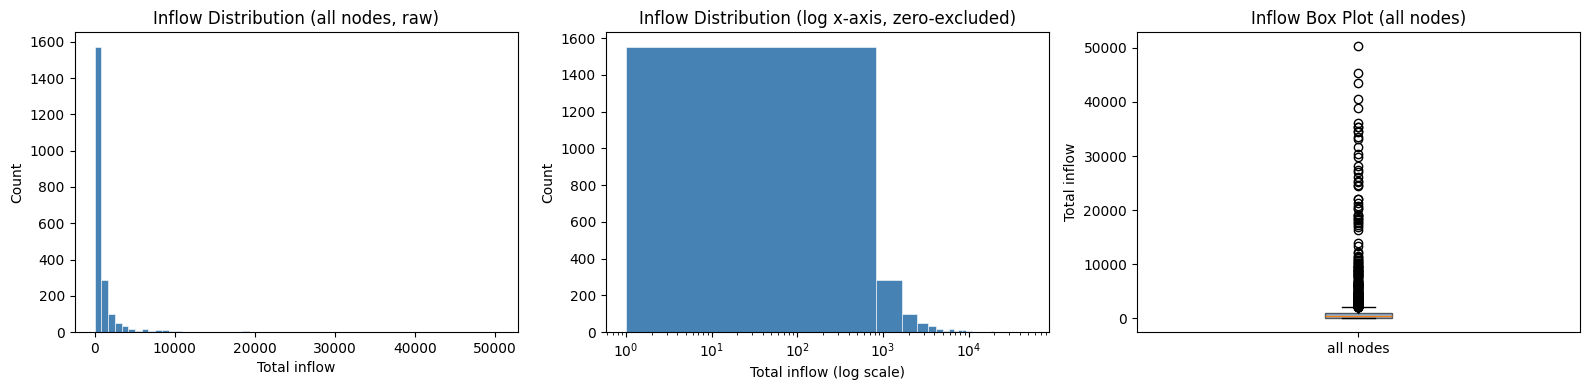

Summary statistics — total inflow (all nodes):


,value
count,2168.000000
mean,1398.358398
std,4049.255371
min,0.000000
25%,182.000000
50%,410.000000
75%,944.750000
90%,2462.900000
95%,4980.450000
99%,24578.400000


In [7]:
# Overall inflow distribution (all 2168 nodes)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw histogram
axes[0].hist(total_inflow, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_title("Inflow Distribution (all nodes, raw)")
axes[0].set_xlabel("Total inflow")
axes[0].set_ylabel("Count")

# Log-scale x-axis to see the long tail
nonzero = total_inflow[total_inflow > 0]
axes[1].hist(nonzero, bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[1].set_xscale("log")
axes[1].set_title("Inflow Distribution (log x-axis, zero-excluded)")
axes[1].set_xlabel("Total inflow (log scale)")
axes[1].set_ylabel("Count")

# Box plot
axes[2].boxplot(total_inflow, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[2].set_title("Inflow Box Plot (all nodes)")
axes[2].set_ylabel("Total inflow")
axes[2].set_xticks([1])
axes[2].set_xticklabels(["all nodes"])

plt.tight_layout()
plt.show()

# Summary statistics
stats = pd.Series(total_inflow).describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
stats["zeros"] = int((total_inflow == 0).sum())
stats["skewness"] = float(pd.Series(total_inflow).skew())
print("Summary statistics — total inflow (all nodes):")
display(stats.to_frame("value"))

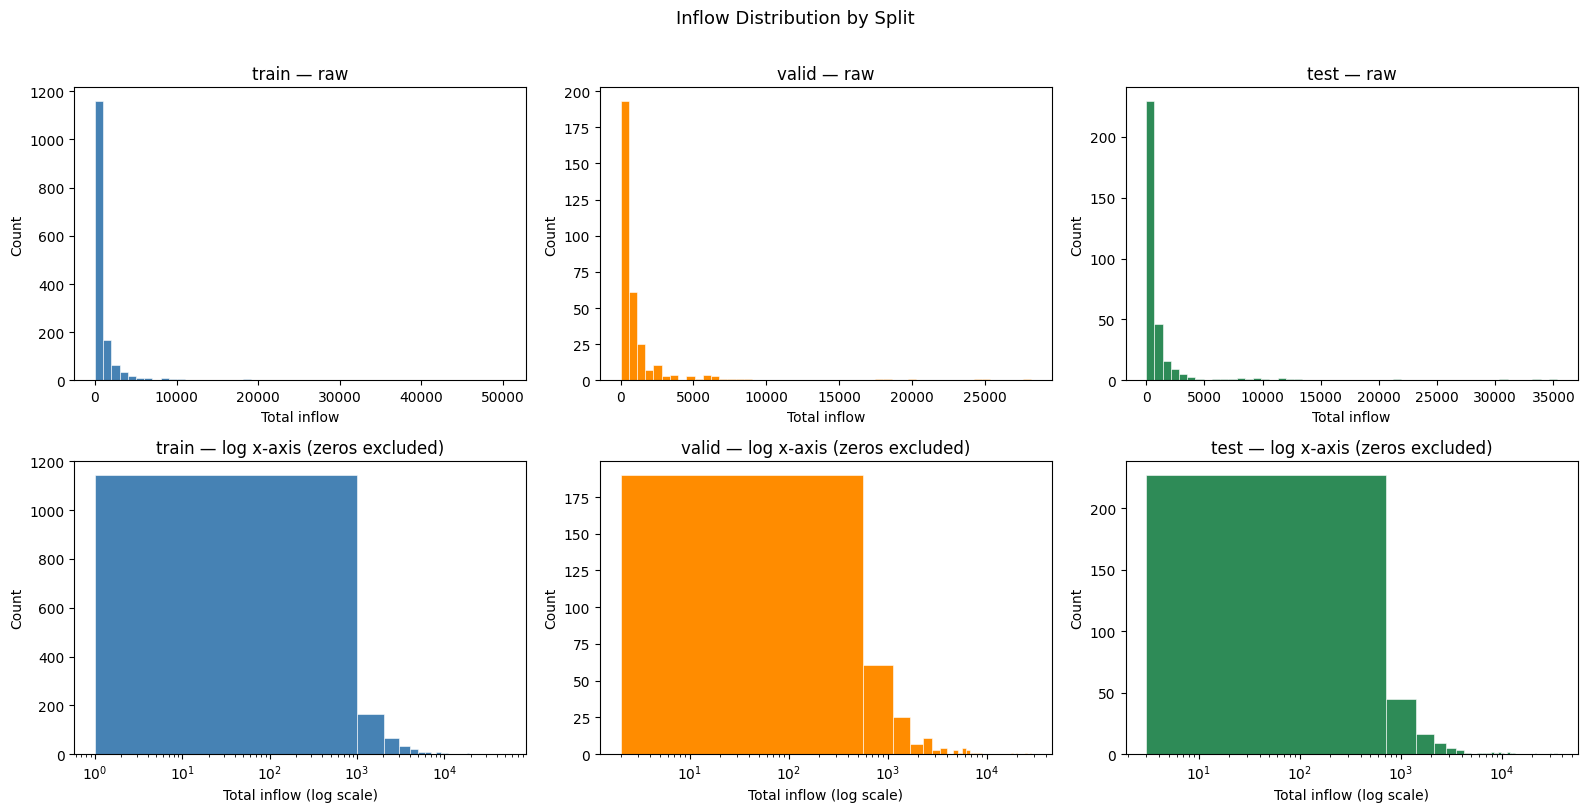

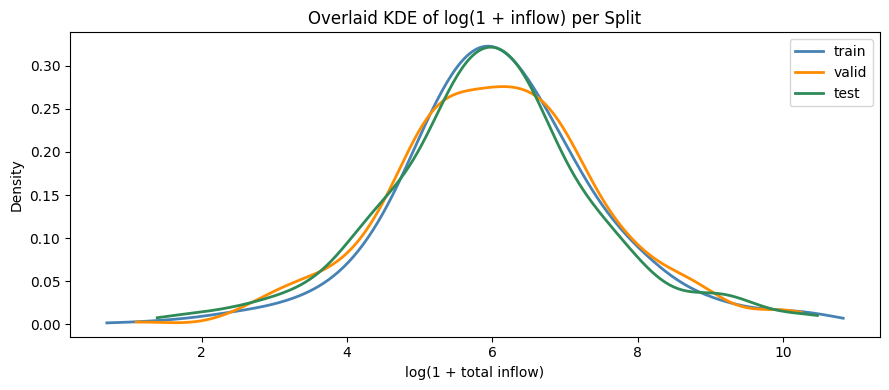

Per-split summary statistics:


,n_nodes,zeros,min,p25,median,mean,p75,p95,max,std,skewness
split,,,,,,,,,,,
train,1517,14,0.0,191.0,414.0,1434.869507,949.0,4848.20,50330.0,4249.962891,6.794569
valid,325,3,0.0,163.0,423.0,1302.181519,1012.0,5715.40,28214.0,3257.909668,5.723763
test,326,3,0.0,171.5,379.5,1324.340454,779.0,5717.75,35299.0,3786.663818,6.427837


In [8]:
# Per-split inflow distributions
splits = {
    "train": total_inflow[idx_train],
    "valid": total_inflow[idx_valid],
    "test":  total_inflow[idx_test],
}
colors = {"train": "steelblue", "valid": "darkorange", "test": "seagreen"}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, (name, vals) in enumerate(splits.items()):
    # Raw histogram
    axes[0, col].hist(vals, bins=50, color=colors[name], edgecolor="white", linewidth=0.4)
    axes[0, col].set_title(f"{name} — raw")
    axes[0, col].set_xlabel("Total inflow")
    axes[0, col].set_ylabel("Count")

    # Log-scale x-axis
    nz = vals[vals > 0]
    axes[1, col].hist(nz, bins=50, color=colors[name], edgecolor="white", linewidth=0.4)
    axes[1, col].set_xscale("log")
    axes[1, col].set_title(f"{name} — log x-axis (zeros excluded)")
    axes[1, col].set_xlabel("Total inflow (log scale)")
    axes[1, col].set_ylabel("Count")

plt.suptitle("Inflow Distribution by Split", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Overlaid log-scale KDE comparison
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9, 4))
for name, vals in splits.items():
    nz = np.log1p(vals[vals > 0])
    kde = gaussian_kde(nz, bw_method=0.3)
    xs = np.linspace(nz.min(), nz.max(), 300)
    ax.plot(xs, kde(xs), label=name, color=colors[name], linewidth=2)

ax.set_xlabel("log(1 + total inflow)")
ax.set_ylabel("Density")
ax.set_title("Overlaid KDE of log(1 + inflow) per Split")
ax.legend()
plt.tight_layout()
plt.show()

# Per-split summary statistics table
rows = []
for name, vals in splits.items():
    s = pd.Series(vals)
    rows.append({
        "split": name,
        "n_nodes": len(vals),
        "zeros": int((vals == 0).sum()),
        "min": float(vals.min()),
        "p25": float(np.percentile(vals, 25)),
        "median": float(np.median(vals)),
        "mean": float(vals.mean()),
        "p75": float(np.percentile(vals, 75)),
        "p95": float(np.percentile(vals, 95)),
        "max": float(vals.max()),
        "std": float(vals.std()),
        "skewness": float(s.skew()),
    })

print("Per-split summary statistics:")
display(pd.DataFrame(rows).set_index("split"))

## 7. Train a Differentiable MLP Regressor

In [9]:
def sqrt_scale(y):
    return np.sqrt(y.astype(np.float32))

def sqrt_unscale(y_scaled):
    return np.clip(y_scaled, 0, None) ** 2

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def mape_positive(y_true, y_pred):
    mask = y_true > 0
    if not mask.any():
        return float("nan")
    return float(np.mean(np.abs(y_true[mask] - y_pred[mask]) / y_true[mask]))

class InflowMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

X = torch.from_numpy(dst_emb).float()
y = torch.from_numpy(sqrt_scale(total_inflow)).float().view(-1, 1)

train_ds = TensorDataset(X[idx_train], y[idx_train])
valid_ds = TensorDataset(X[idx_valid], y[idx_valid])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)

mlp = InflowMLP(dst_emb.shape[1]).to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

best_state = None
best_valid_rmse = float("inf")
best_epoch = -1
epochs_without_improvement = 0
history = []

for epoch in range(1, MAX_EPOCHS + 1):
    mlp.train()
    train_losses = []
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = mlp(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    mlp.eval()
    with torch.no_grad():
        valid_pred_scaled = mlp(X[idx_valid].to(device)).cpu().numpy().reshape(-1)
        train_pred_scaled = mlp(X[idx_train].to(device)).cpu().numpy().reshape(-1)

    valid_pred = sqrt_unscale(valid_pred_scaled)
    train_pred = sqrt_unscale(train_pred_scaled)
    valid_true = total_inflow[idx_valid]
    train_true = total_inflow[idx_train]

    train_rmse = rmse(train_true, train_pred)
    valid_rmse = rmse(valid_true, valid_pred)
    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "train_rmse": train_rmse,
        "valid_rmse": valid_rmse,
    })

    if valid_rmse < best_valid_rmse:
        best_valid_rmse = valid_rmse
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in mlp.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 25 == 0:
        print(f"epoch {epoch:03d} | train RMSE {train_rmse:.3f} | valid RMSE {valid_rmse:.3f}")

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

mlp.load_state_dict(best_state)
print(f"Best validation RMSE: {best_valid_rmse:.3f} at epoch {best_epoch}")

epoch 001 | train RMSE 4354.933 | valid RMSE 3393.427
epoch 025 | train RMSE 601.114 | valid RMSE 474.122
epoch 050 | train RMSE 565.195 | valid RMSE 466.240
epoch 075 | train RMSE 534.995 | valid RMSE 466.358
epoch 100 | train RMSE 522.874 | valid RMSE 471.732
Early stopping at epoch 118.
Best validation RMSE: 449.768 at epoch 18


## 8. Test Results

In [10]:
def evaluate_predictions(y_true, y_pred, name):
    return {
        "split": name,
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "MAPE_pos": mape_positive(y_true, y_pred),
    }

with torch.no_grad():
    pred_scaled_all = mlp(X.to(device)).cpu().numpy().reshape(-1)
pred_all = sqrt_unscale(pred_scaled_all)

results = pd.DataFrame([
    evaluate_predictions(total_inflow[idx_train], pred_all[idx_train], "train"),
    evaluate_predictions(total_inflow[idx_valid], pred_all[idx_valid], "valid"),
    evaluate_predictions(total_inflow[idx_test],  pred_all[idx_test],  "test"),
])

display(results)

gmel_head_results = pd.DataFrame([
    evaluate_predictions(train_inflow[idx_train], inflow_head_pred[idx_train], "train"),
    evaluate_predictions(train_inflow[idx_valid], inflow_head_pred[idx_valid], "valid"),
    evaluate_predictions(train_inflow[idx_test],  inflow_head_pred[idx_test],  "test"),
])

print("Reference only: GMEL's built-in inflow head against TRAIN inflow target")
display(gmel_head_results)

,split,RMSE,MAE,MAPE_pos
0,train,588.093750,237.202194,5.183684
1,valid,449.767609,235.593201,1.364839
2,test,293.837006,185.412094,1.197762


Reference only: GMEL's built-in inflow head against TRAIN inflow target


,split,RMSE,MAE,MAPE_pos
0,train,350.288239,128.601486,9.233951
1,valid,226.275528,126.918831,1.702843
2,test,159.172821,105.976601,1.869316


## 9. Visual Checks

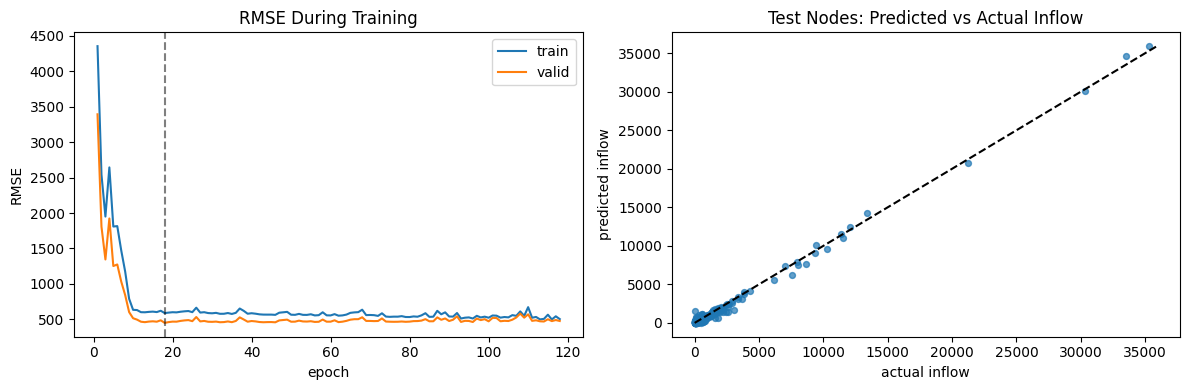

In [11]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_rmse"], label="train")
axes[0].plot(history_df["epoch"], history_df["valid_rmse"], label="valid")
axes[0].axvline(best_epoch, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("RMSE During Training")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("RMSE")
axes[0].legend()

axes[1].scatter(total_inflow[idx_test], pred_all[idx_test], s=18, alpha=0.7)
lo = float(min(total_inflow[idx_test].min(), pred_all[idx_test].min()))
hi = float(max(total_inflow[idx_test].max(), pred_all[idx_test].max()))
axes[1].plot([lo, hi], [lo, hi], linestyle="--", color="black")
axes[1].set_title("Test Nodes: Predicted vs Actual Inflow")
axes[1].set_xlabel("actual inflow")
axes[1].set_ylabel("predicted inflow")

plt.tight_layout()
plt.show()

In [12]:
test_df = pd.DataFrame({
    "node_id": idx_test,
    "actual_total_inflow": total_inflow[idx_test],
    "pred_total_inflow": pred_all[idx_test],
})
test_df["abs_error"] = np.abs(test_df["actual_total_inflow"] - test_df["pred_total_inflow"])

print("Worst test-node errors:")
display(test_df.sort_values("abs_error", ascending=True).head(50))

Worst test-node errors:


,node_id,actual_total_inflow,pred_total_inflow,abs_error
197,1296,119.0,118.781822,0.218178
33,279,9.0,6.995265,2.004735
85,564,396.0,398.045532,2.045532
155,1046,398.0,401.384247,3.384247
235,1530,116.0,112.144753,3.855247
9,76,2866.0,2861.939453,4.060547
257,1633,93.0,87.774544,5.225456
121,828,111.0,116.380394,5.380394
308,2015,196.0,201.519440,5.519440
105,732,808.0,813.581177,5.581177


## 10. Notes

- The new MLP is evaluated on a **held-out node split**, not the original edge split from the OD task.
- The target here is **total inflow per destination node**, aggregated across all OD records in train/valid/test.
- The GMEL inflow head shown above is only a reference baseline. It was originally trained against `train_inflow`, not the new held-out node task.
- If this node-level predictor looks promising, the next step is to discretize inflow into classes and use a node-level counterfactual explainer directly.

## 11. Discretize Total Inflow → Low / Medium / High

Thresholds are derived from the MLP's own predictions on training nodes (mirroring how `cf_gmel_gbrt` uses GBRT predictions) so that the class boundaries are consistent with what the model has learned.

Low  : pred < 285.7
Med  : 285.7 <= pred < 650.4
High : pred >= 650.4

Class distribution across splits:


,Low,Medium,High,total
split,,,,
train,501,515,501,1517
valid,113,102,110,325
test,130,92,104,326
all,744,709,715,2168


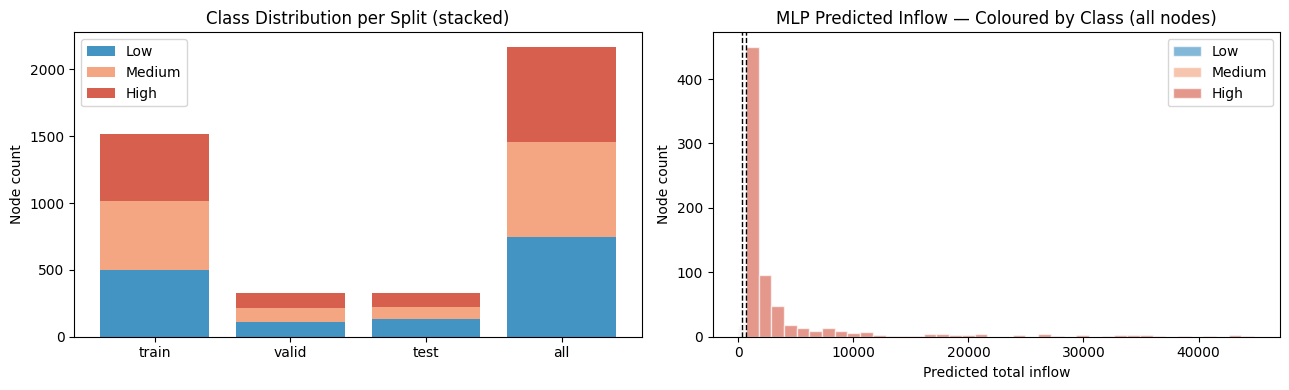

In [13]:
# Thresholds from MLP predictions on training nodes
with torch.no_grad():
    train_preds_scaled = mlp(X[idx_train].to(device)).cpu().numpy().reshape(-1)
train_preds = sqrt_unscale(train_preds_scaled)

LOW_THR_INFLOW  = float(np.percentile(train_preds, 33))
HIGH_THR_INFLOW = float(np.percentile(train_preds, 67))

CLASS_NAMES_INFLOW  = {0: "Low", 1: "Medium", 2: "High"}
CLASS_COLORS_INFLOW = {0: "#4393c3", 1: "#f4a582", 2: "#d6604d"}

def discretize_inflow(pred: float) -> int:
    if pred < LOW_THR_INFLOW:  return 0
    if pred < HIGH_THR_INFLOW: return 1
    return 2

print(f"Low  : pred < {LOW_THR_INFLOW:.1f}")
print(f"Med  : {LOW_THR_INFLOW:.1f} <= pred < {HIGH_THR_INFLOW:.1f}")
print(f"High : pred >= {HIGH_THR_INFLOW:.1f}")

# Class distribution per split (based on pred_all already computed in section 8)
split_labels = {"train": idx_train, "valid": idx_valid, "test": idx_test, "all": np.arange(num_nodes)}
rows = []
for name, idx in split_labels.items():
    classes = [discretize_inflow(p) for p in pred_all[idx]]
    counts = {CLASS_NAMES_INFLOW[c]: classes.count(c) for c in [0, 1, 2]}
    rows.append({"split": name, **counts, "total": len(idx)})
class_dist_df = pd.DataFrame(rows).set_index("split")
print("\nClass distribution across splits:")
display(class_dist_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Stacked bar per split
bottom = np.zeros(4)
splits_ordered = ["train", "valid", "test", "all"]
for cls in [0, 1, 2]:
    vals = [class_dist_df.loc[s, CLASS_NAMES_INFLOW[cls]] for s in splits_ordered]
    axes[0].bar(splits_ordered, vals, bottom=bottom,
                color=CLASS_COLORS_INFLOW[cls], label=CLASS_NAMES_INFLOW[cls])
    bottom += np.array(vals, dtype=float)
axes[0].set_title("Class Distribution per Split (stacked)")
axes[0].set_ylabel("Node count")
axes[0].legend()

# Histogram of predictions coloured by class
for cls in [0, 1, 2]:
    mask = np.array([discretize_inflow(p) for p in pred_all]) == cls
    axes[1].hist(pred_all[mask], bins=40, alpha=0.65,
                 color=CLASS_COLORS_INFLOW[cls], label=CLASS_NAMES_INFLOW[cls], edgecolor="white")
axes[1].axvline(LOW_THR_INFLOW,  color="black", linestyle="--", linewidth=1)
axes[1].axvline(HIGH_THR_INFLOW, color="black", linestyle="--", linewidth=1)
axes[1].set_title("MLP Predicted Inflow — Coloured by Class (all nodes)")
axes[1].set_xlabel("Predicted total inflow")
axes[1].set_ylabel("Node count")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Setup — Import CFExplainer & Prepare Graph

`CFExplainer` requires a `GCNSynthetic` model with `forward(x, adj) → (N, C) log-softmax`. We add the `cf-gnnexplainer/src` directory to the path, then build the dense adjacency tensor and `edge_index` needed by `get_neighbourhood`.

In [14]:
import sys

CF_SRC = r"c:\Users\qshah\Documents\Spring 2026\GMEL\CF-models\cf-gnnexplainer\src"
if CF_SRC not in sys.path:
    sys.path.insert(0, CF_SRC)

# GMEL's utils.py is already cached in sys.modules as 'utils' (a plain module).
# cf_explainer.py internally does `from utils.utils import ...` which requires
# 'utils' to be a *package*. Temporarily evict GMEL's utils so Python can find
# the cf-gnnexplainer utils/ package instead.
_gmel_utils = sys.modules.pop("utils", None)

from gcn import GCNSynthetic
from cf_explanation.cf_explainer import CFExplainer
from utils.utils import get_neighbourhood, normalize_adj   # CF's utils package

# Restore GMEL utils — CF imports are already bound at module level, so this
# doesn't break anything inside CFExplainer.
if _gmel_utils is not None:
    sys.modules["utils"] = _gmel_utils

import torch.nn.functional as F
import networkx as nx
import matplotlib.patches as mpatches

# ── Dense adjacency tensor ────────────────────────────────────────────────────
adj_tensor    = torch.FloatTensor(ct_adj)
feat_tensor   = torch.FloatTensor(node_feats)
norm_adj_full = normalize_adj(adj_tensor)          # (D+I)^{-1/2}(A+I)(D+I)^{-1/2}

# ── Edge index for get_neighbourhood (PyG format) ────────────────────────────
rows, cols      = np.where(ct_adj > 0)
edge_index_full = torch.tensor(np.array([rows, cols]), dtype=torch.long)

# ── Node labels using section-11 thresholds applied to actual total_inflow ───
node_labels_cf = torch.tensor(
    [discretize_inflow(float(v)) for v in total_inflow], dtype=torch.long
)

print("adj_tensor    :", adj_tensor.shape)
print("norm_adj_full :", norm_adj_full.shape)
print("edge_index    :", edge_index_full.shape)
print("node_labels   :", node_labels_cf.shape, "| classes:", node_labels_cf.unique().tolist())

adj_tensor    : torch.Size([2168, 2168])
norm_adj_full : torch.Size([2168, 2168])
edge_index    : torch.Size([2, 13914])
node_labels   : torch.Size([2168]) | classes: [0, 1, 2]


## 13. Train GCNSynthetic for Node Inflow Classification

Train a 3-layer `GCNSynthetic` on the node-level inflow classification task. This is the model `CFExplainer` will explain — it uses raw node features + the census-tract adjacency, so its decisions are graph-structure-aware.

In [15]:
GCN_NHID    = 64
GCN_DROPOUT = 0.0
GCN_LR      = 1e-3
GCN_EPOCHS  = 500
GCN_PATIENCE = 50
NUM_CLASSES  = 3

torch.manual_seed(SEED)
gcn_model = GCNSynthetic(
    nfeat=node_feats.shape[1],
    nhid=GCN_NHID,
    nout=GCN_NHID,
    nclass=NUM_CLASSES,
    dropout=GCN_DROPOUT,
)
gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=GCN_LR, weight_decay=1e-4)

best_gcn_state  = None
best_val_acc    = 0.0
patience_count  = 0

for epoch in range(1, GCN_EPOCHS + 1):
    gcn_model.train()
    gcn_optimizer.zero_grad()
    out = gcn_model(feat_tensor, norm_adj_full)
    loss = F.nll_loss(out[idx_train], node_labels_cf[idx_train])
    loss.backward()
    gcn_optimizer.step()

    gcn_model.eval()
    with torch.no_grad():
        out_val = gcn_model(feat_tensor, norm_adj_full)
    val_acc = (out_val[idx_valid].argmax(1) == node_labels_cf[idx_valid]).float().mean().item()

    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_gcn_state = {k: v.clone() for k, v in gcn_model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | loss {loss.item():.4f} | val acc {val_acc:.3f}")

    if patience_count >= GCN_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

gcn_model.load_state_dict(best_gcn_state)
gcn_model.eval()

with torch.no_grad():
    out_test = gcn_model(feat_tensor, norm_adj_full)
test_acc = (out_test[idx_test].argmax(1) == node_labels_cf[idx_test]).float().mean().item()
train_acc = (out_test[idx_train].argmax(1) == node_labels_cf[idx_train]).float().mean().item()
print(f"\nBest val acc: {best_val_acc:.3f} | Train acc: {train_acc:.3f} | Test acc: {test_acc:.3f}")

Epoch 001 | loss 1.1057 | val acc 0.335
Epoch 050 | loss 0.7984 | val acc 0.615
Early stopping at epoch 87.

Best val acc: 0.649 | Train acc: 0.600 | Test acc: 0.549


## 14. Pick Target Node & Extract k-hop Subgraph

`get_neighbourhood` (from `utils/utils.py`) uses PyG's `k_hop_subgraph` to extract the dense adjacency and re-indexed features around the target node — exactly the format `CFExplainer` expects.

In [16]:
# ── Config ───────────────────────────────────────────────────────────────────
TARGET_NODE_CF = 641   # change to explain any node
N_HOPS_CF      = 2
# ─────────────────────────────────────────────────────────────────────────────

sub_adj_cf, sub_feat_cf, sub_labels_cf, node_dict_cf = get_neighbourhood(
    node_idx=TARGET_NODE_CF,
    edge_index=edge_index_full,
    n_hops=N_HOPS_CF,
    features=feat_tensor,
    labels=node_labels_cf,
)
new_idx_cf    = node_dict_cf[TARGET_NODE_CF]
idx_to_node   = {v: k for k, v in node_dict_cf.items()}  # reverse map

with torch.no_grad():
    out_full = gcn_model(feat_tensor, norm_adj_full)
y_pred_orig_cf = int(out_full[TARGET_NODE_CF].argmax())

print("=" * 50)
print(f"Target node        : {TARGET_NODE_CF}")
print(f"Subgraph size      : {sub_adj_cf.shape[0]} nodes  (new_idx={new_idx_cf})")
print(f"GCN prediction     : {CLASS_NAMES_INFLOW[y_pred_orig_cf]} (class {y_pred_orig_cf})")
print(f"True label         : {CLASS_NAMES_INFLOW[int(node_labels_cf[TARGET_NODE_CF])]}")
print(f"Actual total inflow: {float(total_inflow[TARGET_NODE_CF]):.1f}")
print("=" * 50)

Target node        : 641
Subgraph size      : 27 nodes  (new_idx=13)
GCN prediction     : High (class 2)
True label         : Low
Actual total inflow: 70.0


## 15. Run CFExplainer

`CFExplainer` internally instantiates `GCNSyntheticPerturb`, copies the frozen GCN weights, and gradient-optimizes a perturbation mask `P` over edges in the subgraph. It records any epoch where the predicted class flips as a counterfactual example.

> **Note:** CFExplainer prints one line per epoch by default — expect ~500 lines of output.

In [17]:
CF_BETA      = 0.5    # graph-distance weight; lower = more edge changes allowed
CF_LR        = 0.1
CF_MOMENTUM  = 0.0
CF_EPOCHS    = 500
CF_OPTIMIZER = "SGD"

explainer = CFExplainer(
    model=gcn_model,
    sub_adj=sub_adj_cf,
    sub_feat=sub_feat_cf,
    n_hid=GCN_NHID,
    dropout=GCN_DROPOUT,
    sub_labels=sub_labels_cf,
    y_pred_orig=torch.tensor(y_pred_orig_cf),
    num_classes=NUM_CLASSES,
    beta=CF_BETA,
    device="cpu",
)

cf_example = explainer.explain(
    cf_optimizer=CF_OPTIMIZER,
    node_idx=TARGET_NODE_CF,
    new_idx=new_idx_cf,
    lr=CF_LR,
    n_momentum=CF_MOMENTUM,
    num_epochs=CF_EPOCHS,
)

print(f"\nTotal CF examples recorded: {len(cf_example)}")

orig model requires_grad:  gc1.weight True
orig model requires_grad:  gc1.bias True
orig model requires_grad:  gc2.weight True
orig model requires_grad:  gc2.bias True
orig model requires_grad:  gc3.weight True
orig model requires_grad:  gc3.bias True
orig model requires_grad:  lin.weight True
orig model requires_grad:  lin.bias True
cf model requires_grad:  P_vec True
cf model requires_grad:  gc1.weight False
cf model requires_grad:  gc1.bias False
cf model requires_grad:  gc2.weight False
cf model requires_grad:  gc2.bias False
cf model requires_grad:  gc3.weight False
cf model requires_grad:  gc3.bias False
cf model requires_grad:  lin.weight False
cf model requires_grad:  lin.bias False
Node idx: 641 New idx: 13 Epoch: 0001 loss: -0.1396 pred loss: -0.1396 graph loss: 0.0000
Output: tensor([-3.2288, -2.4005, -0.1396])
 Output nondiff: tensor([-3.3689, -2.4673, -0.1270])
 orig pred: 2, new pred: 2, new pred nondiff: 2
 
Node idx: 641 New idx: 13 Epoch: 0002 loss: -0.1397 pred loss: 

c:\Users\qshah\Documents\Spring 2026\GMEL\CF-models\cf-gnnexplainer\src\cf_explanation\cf_explainer.py:99: UserWarning: torch.nn.utils.clip_grad_norm is now deprecated in favor of torch.nn.utils.clip_grad_norm_.
  clip_grad_norm(self.cf_model.parameters(), 2.0)


Node idx: 641 New idx: 13 Epoch: 0098 loss: -0.1533 pred loss: -0.1533 graph loss: 0.0000
Output: tensor([-3.1137, -2.3255, -0.1533])
 Output nondiff: tensor([-3.3689, -2.4673, -0.1270])
 orig pred: 2, new pred: 2, new pred nondiff: 2
 
Node idx: 641 New idx: 13 Epoch: 0099 loss: -0.1535 pred loss: -0.1535 graph loss: 0.0000
Output: tensor([-3.1123, -2.3246, -0.1535])
 Output nondiff: tensor([-3.3689, -2.4673, -0.1270])
 orig pred: 2, new pred: 2, new pred nondiff: 2
 
Node idx: 641 New idx: 13 Epoch: 0100 loss: -0.1537 pred loss: -0.1537 graph loss: 0.0000
Output: tensor([-3.1108, -2.3236, -0.1537])
 Output nondiff: tensor([-3.3689, -2.4673, -0.1270])
 orig pred: 2, new pred: 2, new pred nondiff: 2
 
Node idx: 641 New idx: 13 Epoch: 0101 loss: -0.1539 pred loss: -0.1539 graph loss: 0.0000
Output: tensor([-3.1093, -2.3226, -0.1539])
 Output nondiff: tensor([-3.3689, -2.4673, -0.1270])
 orig pred: 2, new pred: 2, new pred nondiff: 2
 
Node idx: 641 New idx: 13 Epoch: 0102 loss: -0.1541 

## 16. Results — Parse CF & Visualize Subgraph

Original class : High (class 2)
CF class       : Low (class 0)
Total loss     : 2.0000
Edges changed  : 4

Edges removed : 4
  635 -- 641
  636 -- 641
  639 -- 641
  641 -- 1092
Edges added   : 0


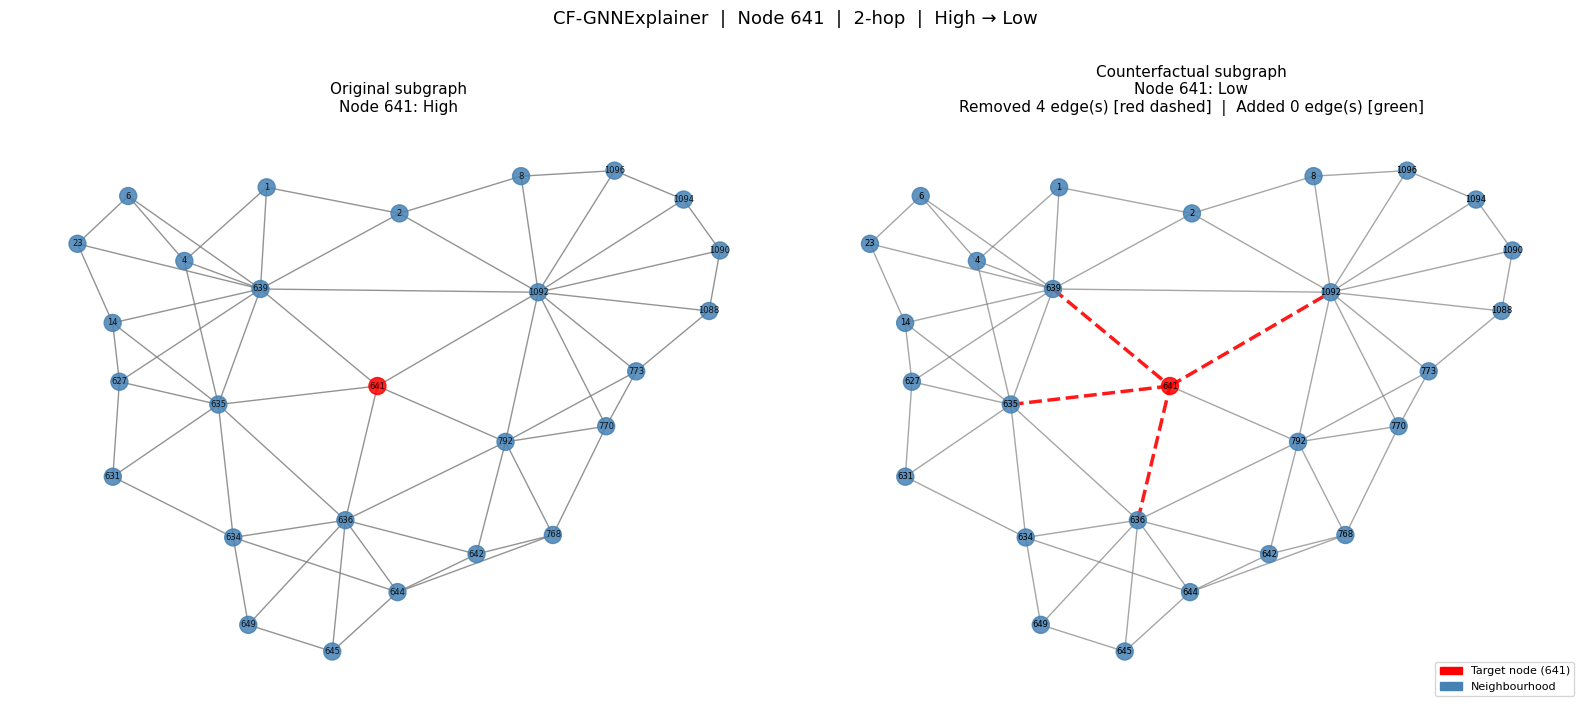

In [18]:
if not cf_example:
    print("No CF found. Try reducing CF_BETA, increasing CF_EPOCHS, or changing TARGET_NODE_CF.")
else:
    # cf_example[-1] is the best CF (lowest total loss)
    best = cf_example[-1]
    orig_class  = best[4]          # [4] y_pred_orig
    cf_class    = best[6]          # [6] y_pred_new (thresholded, actual flip)
    cf_adj_np   = best[2]          # [2] perturbed adjacency (numpy)
    orig_adj_np = best[3]          # [3] original subgraph adjacency (numpy)
    n_sub       = best[8]          # [8] number of subgraph nodes
    loss_total  = best[9]
    loss_graph  = best[11]         # [11] graph distance = number of edges changed

    print("=" * 50)
    print(f"Original class : {CLASS_NAMES_INFLOW[orig_class]} (class {orig_class})")
    print(f"CF class       : {CLASS_NAMES_INFLOW[cf_class]} (class {cf_class})")
    print(f"Total loss     : {loss_total:.4f}")
    print(f"Edges changed  : {loss_graph:.0f}")
    print("=" * 50)

    # Identify changed edges (i < j to avoid duplicates in undirected graph)
    diff = cf_adj_np - orig_adj_np
    removed_edges = [(i, j) for i in range(n_sub) for j in range(i+1, n_sub) if diff[i, j] < -0.5]
    added_edges   = [(i, j) for i in range(n_sub) for j in range(i+1, n_sub) if diff[i, j] >  0.5]

    print(f"\nEdges removed : {len(removed_edges)}")
    for i, j in removed_edges:
        print(f"  {idx_to_node.get(i, i)} -- {idx_to_node.get(j, j)}")
    print(f"Edges added   : {len(added_edges)}")
    for i, j in added_edges:
        print(f"  {idx_to_node.get(i, i)} -- {idx_to_node.get(j, j)}")

    # ── Visualize ─────────────────────────────────────────────────────────────
    G_orig = nx.from_numpy_array(orig_adj_np)
    G_cf   = nx.from_numpy_array(cf_adj_np)
    node_colors = ["red" if k == new_idx_cf else "steelblue" for k in range(n_sub)]
    pos = nx.spring_layout(G_orig, seed=42)
    node_labels_draw = {k: idx_to_node.get(k, k) for k in range(n_sub)}

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    nx.draw_networkx(G_orig, pos=pos, ax=axes[0], node_color=node_colors, node_size=150,
                     with_labels=True, labels=node_labels_draw,
                     font_size=6, edge_color="gray", alpha=0.85)
    axes[0].set_title(
        f"Original subgraph\nNode {TARGET_NODE_CF}: {CLASS_NAMES_INFLOW[orig_class]}", fontsize=11)
    axes[0].axis("off")

    unchanged = [(u, v) for u, v in G_cf.edges() if G_orig.has_edge(u, v)
                 and (u, v) not in removed_edges and (v, u) not in removed_edges]
    nx.draw_networkx_nodes(G_cf, pos=pos, ax=axes[1], node_color=node_colors, node_size=150, alpha=0.85)
    nx.draw_networkx_labels(G_cf, pos=pos, ax=axes[1], labels=node_labels_draw, font_size=6)
    nx.draw_networkx_edges(G_cf, pos=pos, ax=axes[1], edgelist=unchanged, edge_color="gray", alpha=0.7)
    if removed_edges:
        nx.draw_networkx_edges(G_orig, pos=pos, ax=axes[1], edgelist=removed_edges,
                               edge_color="red", style="dashed", width=2.5, alpha=0.9)
    if added_edges:
        nx.draw_networkx_edges(G_cf, pos=pos, ax=axes[1], edgelist=added_edges,
                               edge_color="green", width=2.5, alpha=0.9)

    axes[1].set_title(
        f"Counterfactual subgraph\nNode {TARGET_NODE_CF}: {CLASS_NAMES_INFLOW[cf_class]}\n"
        f"Removed {len(removed_edges)} edge(s) [red dashed]  |  Added {len(added_edges)} edge(s) [green]",
        fontsize=11)
    axes[1].axis("off")
    axes[1].legend(handles=[
        mpatches.Patch(color="red",       label=f"Target node ({TARGET_NODE_CF})"),
        mpatches.Patch(color="steelblue", label="Neighbourhood"),
    ], fontsize=8, loc="lower right")

    plt.suptitle(
        f"CF-GNNExplainer  |  Node {TARGET_NODE_CF}  |  {N_HOPS_CF}-hop  |  "
        f"{CLASS_NAMES_INFLOW[orig_class]} → {CLASS_NAMES_INFLOW[cf_class]}",
        fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 17. Multi-Node CF Scan

Run `CFExplainer` across several test nodes. Per-epoch printing is suppressed. `beta` is lowered to give the optimizer more room to change edges.

In [19]:
import io, contextlib

# ─────────────────────────────────────────────────────────────────────────────
# WHY CFs FAIL: if GCNSynthetic classifies using node features alone, edge
# perturbations carry no gradient signal. Fix: retrain with structural features
# (weighted degree, 2-hop degree) so the GCN MUST use message-passing.
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: build graph-structural features ───────────────────────────────────
w_degree   = ct_adj.sum(axis=1, keepdims=True).astype(np.float32)       # weighted degree
hop2_degree = (ct_adj @ ct_adj).sum(axis=1, keepdims=True).astype(np.float32)  # 2-hop reach

struct_np  = np.concatenate([w_degree, hop2_degree], axis=1)
struct_np  = (struct_np - struct_np.mean(0)) / (struct_np.std(0) + 1e-8)
struct_feat = torch.FloatTensor(struct_np)
print(f"Structural features: {struct_feat.shape}  (weighted-degree, 2-hop-degree)")

# ── Step 2: retrain a new GCNSynthetic with structural features ───────────────
GCN_NHID_S    = 64
GCN_DROPOUT_S = 0.5      # high dropout forces reliance on aggregated neighbours
GCN_LR_S      = 1e-3
GCN_EPOCHS_S  = 500
GCN_PAT_S     = 50

torch.manual_seed(SEED)
gcn_struct = GCNSynthetic(
    nfeat=struct_feat.shape[1], nhid=GCN_NHID_S,
    nout=GCN_NHID_S, nclass=NUM_CLASSES, dropout=GCN_DROPOUT_S,
)
opt_struct = torch.optim.Adam(gcn_struct.parameters(), lr=GCN_LR_S, weight_decay=1e-4)

best_ss, best_acc_ss, pat_ss = None, 0.0, 0
for epoch in range(1, GCN_EPOCHS_S + 1):
    gcn_struct.train(); opt_struct.zero_grad()
    out_s = gcn_struct(struct_feat, norm_adj_full)
    F.nll_loss(out_s[idx_train], node_labels_cf[idx_train]).backward()
    opt_struct.step()

    gcn_struct.eval()
    with torch.no_grad():
        out_sv = gcn_struct(struct_feat, norm_adj_full)
    va = (out_sv[idx_valid].argmax(1) == node_labels_cf[idx_valid]).float().mean().item()
    if va > best_acc_ss:
        best_acc_ss = va
        best_ss = {k: v.clone() for k, v in gcn_struct.state_dict().items()}
        pat_ss = 0
    else:
        pat_ss += 1
    if epoch % 100 == 0 or epoch == 1:
        print(f"  Epoch {epoch:03d} | val acc {va:.3f}")
    if pat_ss >= GCN_PAT_S:
        print(f"  Early stopping at epoch {epoch}")
        break

gcn_struct.load_state_dict(best_ss); gcn_struct.eval()
with torch.no_grad():
    out_full_s  = gcn_struct(struct_feat, norm_adj_full)
    out_ident_s = gcn_struct(struct_feat, torch.eye(num_nodes))

test_acc_s = (out_full_s[idx_test].argmax(1) == node_labels_cf[idx_test]).float().mean().item()
agree_s    = int((out_full_s.argmax(1) == out_ident_s.argmax(1)).sum())
print(f"\nStructural GCN — test acc: {test_acc_s:.3f}")
print(f"adj vs identity agree: {agree_s}/{num_nodes} ({100*agree_s/num_nodes:.1f}%)")
print("(Lower % = more graph-sensitive = easier to find CFs)")

# ── Step 3: multi-node CF scan ────────────────────────────────────────────────
N_SCAN      = 20
SCAN_EPOCHS = 1000
SCAN_HOPS   = 2
BETA_VALUES = [0.5, 0.1, 0.0]
SCAN_LR     = 0.01
SCAN_OPT    = "Adadelta"

scan_nodes   = idx_test[:N_SCAN]
scan_results = []
print("\n── CF scan (structural GCN) ──")

for node_id in scan_nodes:
    node_id = int(node_id)
    y_pred  = int(out_full_s[node_id].argmax())

    sub_adj_s, sub_feat_s, sub_labels_s, node_dict_s = get_neighbourhood(
        node_idx=node_id, edge_index=edge_index_full,
        n_hops=SCAN_HOPS, features=struct_feat, labels=node_labels_cf,
    )
    new_idx_s = node_dict_s[node_id]

    cf_ex, used_beta = [], None
    for beta_try in BETA_VALUES:
        exp_s = CFExplainer(
            model=gcn_struct, sub_adj=sub_adj_s, sub_feat=sub_feat_s,
            n_hid=GCN_NHID_S, dropout=GCN_DROPOUT_S,
            sub_labels=sub_labels_s, y_pred_orig=torch.tensor(y_pred),
            num_classes=NUM_CLASSES, beta=beta_try, device="cpu",
        )
        # Allow both edge additions and deletions
        exp_s.cf_model.edge_additions = True
        exp_s.cf_model.P_vec = torch.nn.Parameter(torch.zeros(exp_s.cf_model.P_vec_size))

        with contextlib.redirect_stdout(io.StringIO()):
            cf_ex = exp_s.explain(
                cf_optimizer=SCAN_OPT, node_idx=node_id, new_idx=new_idx_s,
                lr=SCAN_LR, n_momentum=0.0, num_epochs=SCAN_EPOCHS,
            )
        if cf_ex:
            used_beta = beta_try
            break

    found = bool(cf_ex)
    if found:
        best_s     = cf_ex[-1]
        cf_class_s = best_s[6]; edges_chgd = int(round(best_s[11]))
        diff_s     = best_s[2] - best_s[3]; n_sub_s = best_s[8]
        idx2node_s = {v: k for k, v in node_dict_s.items()}
        removed_s  = [(idx2node_s.get(i,i), idx2node_s.get(j,j))
                      for i in range(n_sub_s) for j in range(i+1,n_sub_s) if diff_s[i,j]<-0.5]
        added_s    = [(idx2node_s.get(i,i), idx2node_s.get(j,j))
                      for i in range(n_sub_s) for j in range(i+1,n_sub_s) if diff_s[i,j]>0.5]
    else:
        cf_class_s = edges_chgd = None; removed_s = added_s = []

    scan_results.append({
        "node_id": node_id,
        "true_label": CLASS_NAMES_INFLOW[int(node_labels_cf[node_id])],
        "pred_class": CLASS_NAMES_INFLOW[y_pred],
        "cf_found": found,
        "cf_class": CLASS_NAMES_INFLOW[cf_class_s] if found else "—",
        "beta_used": used_beta if found else "—",
        "edges_changed": edges_chgd if found else "—",
        "subgraph_size": int(sub_adj_s.shape[0]),
        "removed": removed_s, "added": added_s,
    })
    status = (f"CF: {CLASS_NAMES_INFLOW[y_pred]} -> {CLASS_NAMES_INFLOW[cf_class_s]} "
              f"({edges_chgd} edges, beta={used_beta})" if found else "no CF")
    print(f"  Node {node_id:4d} | pred={CLASS_NAMES_INFLOW[y_pred]:6s} | {status}")

n_found = sum(r["cf_found"] for r in scan_results)
print(f"\nCF found for {n_found} / {N_SCAN} nodes")

Structural features: torch.Size([2168, 2])  (weighted-degree, 2-hop-degree)
  Epoch 001 | val acc 0.385
  Early stopping at epoch 83

Structural GCN — test acc: 0.460
adj vs identity agree: 1927/2168 (88.9%)
(Lower % = more graph-sensitive = easier to find CFs)

── CF scan (structural GCN) ──
orig model requires_grad:  gc1.weight True
orig model requires_grad:  gc1.bias True
orig model requires_grad:  gc2.weight True
orig model requires_grad:  gc2.bias True
orig model requires_grad:  gc3.weight True
orig model requires_grad:  gc3.bias True
orig model requires_grad:  lin.weight True
orig model requires_grad:  lin.bias True
cf model requires_grad:  P_vec True
cf model requires_grad:  gc1.weight False
cf model requires_grad:  gc1.bias False
cf model requires_grad:  gc2.weight False
cf model requires_grad:  gc2.bias False
cf model requires_grad:  gc3.weight False
cf model requires_grad:  gc3.bias False
cf model requires_grad:  lin.weight False
cf model requires_grad:  lin.bias False
  Node

In [20]:
# Summary table
df_scan = pd.DataFrame([{
    "node_id"       : r["node_id"],
    "true_label"    : r["true_label"],
    "pred_class"    : r["pred_class"],
    "cf_found"      : r["cf_found"],
    "cf_class"      : r["cf_class"],
    "edges_changed" : r["edges_changed"],
    "subgraph_size" : r["subgraph_size"],
} for r in scan_results])
display(df_scan)

# Detail: edge changes for successful CFs
for r in scan_results:
    if r["cf_found"]:
        print(f"\nNode {r['node_id']}  ({r['pred_class']} -> {r['cf_class']}):")
        for u, v in r["removed"]:
            print(f"  REMOVE  {u} -- {v}")
        for u, v in r["added"]:
            print(f"  ADD     {u} -- {v}")

,node_id,true_label,pred_class,cf_found,cf_class,edges_changed,subgraph_size
0,5,High,High,True,Low,56,21
1,13,Medium,Low,True,High,190,22
2,37,High,High,True,Low,120,23
3,41,High,Low,True,High,313,29
4,42,High,Low,True,High,122,23
5,49,High,Low,True,High,213,24
6,52,High,Low,True,High,162,24
7,63,High,High,True,Low,390,40
8,65,High,Low,True,High,131,23
9,76,High,Low,True,High,152,20



Node 5  (High -> Low):
  REMOVE  3 -- 7
  REMOVE  3 -- 287
  REMOVE  3 -- 632
  REMOVE  5 -- 7
  REMOVE  5 -- 11
  REMOVE  5 -- 15
  REMOVE  5 -- 627
  REMOVE  5 -- 629
  REMOVE  5 -- 630
  REMOVE  7 -- 11
  REMOVE  7 -- 287
  REMOVE  7 -- 629
  REMOVE  7 -- 632
  REMOVE  7 -- 633
  REMOVE  11 -- 14
  REMOVE  11 -- 15
  REMOVE  11 -- 19
  REMOVE  11 -- 31
  REMOVE  11 -- 285
  REMOVE  11 -- 286
  REMOVE  11 -- 287
  REMOVE  11 -- 633
  REMOVE  14 -- 15
  REMOVE  14 -- 19
  REMOVE  14 -- 28
  REMOVE  14 -- 31
  REMOVE  14 -- 627
  REMOVE  14 -- 635
  REMOVE  14 -- 639
  REMOVE  15 -- 19
  REMOVE  15 -- 28
  REMOVE  15 -- 31
  REMOVE  15 -- 627
  REMOVE  19 -- 31
  REMOVE  19 -- 285
  REMOVE  28 -- 31
  REMOVE  286 -- 287
  REMOVE  627 -- 629
  REMOVE  627 -- 630
  REMOVE  627 -- 631
  REMOVE  627 -- 635
  REMOVE  627 -- 639
  REMOVE  629 -- 630
  REMOVE  629 -- 632
  REMOVE  630 -- 631
  REMOVE  630 -- 632
  REMOVE  630 -- 634
  REMOVE  631 -- 632
  REMOVE  631 -- 633
  REMOVE  631 -- 

In [21]:
gcn_model.eval()

with torch.no_grad():
    out_adj = gcn_model(sub_feat_cf, normalize_adj(sub_adj_cf))
    out_eye = gcn_model(sub_feat_cf, torch.eye(sub_adj_cf.shape[0]))

print("with adjacency:", out_adj[new_idx_cf].argmax().item())
print("identity only :", out_eye[new_idx_cf].argmax().item())
print("logit/prob diff:", torch.abs(out_adj[new_idx_cf] - out_eye[new_idx_cf]))

with adjacency: 2
identity only : 0
logit/prob diff: tensor([3.0693, 0.7389, 2.3828])
